# MoA로 금융 조사 보고서 자동 생성하기

- MoA: Mixture of Agents
    - 여러개의 agent를 돌려서 결과물을 얻는 것
    - ex) genspark
    - 장점: 편향된 사고를 줄일 수 있음

# 1. API 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

# 2. EXA SEARCH


In [2]:
from typing import TypedDict, Annotated
import operator
from exa_py import Exa
from langchain.tools import tool

# EXA 클라이언트 초기화
exa_client = Exa(api_key=os.environ["EXA_API_KEY"])

@tool
def exa_search(query: str, num_results: int = 5) -> str:
    """
    EXA API를 사용하여 웹 검색을 수행합니다.
    각 에이전트가 자신의 관점에 맞는 검색 쿼리로 호출합니다.
    """
    results = exa_client.search_and_contents(
        query=query,
        num_results=num_results,
        text={"max_characters": 1000},
        highlights={"num_sentences": 3}
    )
    
    output = []
    for r in results.results:
        section = f"[{r.title}]\n   URL: {r.url}"
        if r.highlights:
            section += f"\n   핵심: {' '.join(r.highlights)}"
        if hasattr(r, 'text') and r.text:
            section += f"\n   본문: {r.text[:1000]}..."
        output.append(section)
    
    return "\n\n".join(output) if output else "검색 결과 없음"

- 간단한 실험

In [4]:
test = exa_search.invoke("2025 글로벌 반도체 시장 전망", num_results=2)

In [8]:
print(test[:3000])

[2025 글로벌 반도체 산업 전망]
   URL: https://kpmg.com/kr/ko/insights/eri/2025/gtl-0430.html
   핵심: 2025 글로벌 반도체 산업 전망

---

KPMG ‘2025 글로벌 반도체 산업 전망’ 보고서(2025 Global Semiconductor Industry Outlook)는 올해로 20번째 발간되었습니다. 전 세계 반도체 기업 C-level 임원 156명을 대상으로 진행된 설문조사 결과를 바탕으로 반도체 시장의 전망과 전략 과제를 분석했습니다. 조사에 따르면, 응답자의 86%는 2025년 자사 매출이 전년 대비 증가할 것으로 전망했습니다. 또한 72%는 R&D 지출 증가를 계획하고 있어 기술 혁신에 대한 업계의 기대감이 드러났습니다.

향후 3년간 반도체 산업이 직면할 최대 이슈로는 ‘자국 중심주의와 관세’가 꼽혔습니다. 이에 따라 공급망 다변화와 유연성 확보가 기업들의 최우선 전략 과제로 부상했습니다. 인재 확보 문제도 3년 연속 주요 과제로 지목되었습니다. 빅테크, 모빌리티 기업 등 비전통적 반도체 기업들이 기술 역량을 강화하면서, 업계는 신규 경쟁자와의 인재 쟁탈전 심화에 대한 우려를 나타냈습니다.

생성형 AI(인공지능)는 KPMG ‘글로벌 반도체 산업 전망’ 연례 조사 최초로, 반도체 기업 수익을 견인하는 가장 중요한 성장 동인으로 선정되며, 산업 구조가 AI 중심으로 재편되고 있음을 시사했습니다.

본 보고서가 기업이 급변하는 시장 환경에 선제적으로 대응하고, 중장기 전략을 정립하는 데 도움이 되기를 기대합니다.

### 보고서

---
   본문: 2025 글로벌 반도체 산업 전망

---

KPMG ‘2025 글로벌 반도체 산업 전망’ 보고서(2025 Global Semiconductor Industry Outlook)는 올해로 20번째 발간되었습니다. 전 세계 반도체 기업 C-level 임원 156명을 대상으로 진행된 설문조사 결과를 바탕으로 반도체 시장의 전망과 전략 과제를 분

# 3. 관점별 리서치 에이전트 구현

1. 시장 분석 에이전트: 시장 동향, 주가, 트렌드 ex) 삼전의 반도체 시장 점유율 2025
2. 리스크 분석 에이전트: 리스크 요인, 규제, 위협 검색 ex) 반도체 수출 규제 리스크
3. 기회 탐색 에이전트: 투자 기회, 성장 동력, 혁신 검색 ex) AI 반도체 투자 기회 성장
4. Aggregator: 3개의 조사 결과를 통합 보고서로 작성

In [ ]:
# 상태 정의 => 중간 결과물 저장

class MoAState(TypedDict, total=False):
    """금융 조사 MoA 상태 - 3개 관점별 리포트가 별도 필드에 저장됨"""
    user_input: str  # 조사 주제 (예: "삼성전자 반도체 사업 전망")
    market_report: str  # 시장 분석 에이전트의 리포트
    risk_report: str    # 리스크 분석 에이전트의 리포트
    opportunity_report: str  # 기회 탐색 에이전트의 리포트
    final_answer: str   # Aggregator가 작성한 통합 보고서
# responses 필드는 삭제 (개별 관점 리포트 별도 저장용 필드 도입)

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware, ToolRetryMiddleware
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from datetime import datetime

# 여기서 exa_search 툴만 1초에 5회(rps=5) 제한하도록 설정
exa_tool_limit_middleware = ToolCallLimitMiddleware(
    tool_name="exa_search",
    thread_limit=5,   # 동시에 5개까지
    run_limit=5       # 최근 1초 내 최대 5번까지 호출 허용 (rps 제어)
)

# Retry 미들웨어도 추가 (최대 3회, backoff factor 2.0, 초기 지연 1초)
exa_tool_retry_middleware = ToolRetryMiddleware(
    max_retries=3,
    backoff_factor=2.0,
    initial_delay=1.0
)

today = datetime.today().strftime('%Y-%m-%d')
date_prompt=f"""
!!!!! 반드시 주의 !!!!!
[중요] 오늘 날짜는 반드시 {today}입니다. 
절대로 이전 연도(2023/2024 등)가 아닌, {today} 기준으로만 분석하세요.
날짜를 임의로 유추해서 쓰지 말 것.\n"""

# 시장 분석 에이전트 세팅
market_system_prompt = date_prompt+f"""
당신은 주어진 기업이 속한 산업 분석 전문가입니다.
exa_search로 받은 검색 결과를 바탕으로 입력 주제에 대해 아래와 같이 산업 분석 리포트를 작성하세요.

- 현재 시장 규모 및 동향
- 주요 플레이어 및 시장 점유율
- 최근 실적 및 재무 지표
- 시장 전망 (단기/중기)

검색 결과에 기반하여 팩트 중심으로 한국어로 작성하세요."""

_market_agent_core = create_agent(
    model="gpt-4.1-mini",
    tools=[exa_search],
    system_prompt=market_system_prompt,
    middleware=[
        exa_tool_limit_middleware,
        exa_tool_retry_middleware
    ]
)

def market_agent(state: MoAState) -> dict:
    """
    MoAState(state)를 받아 '산업 분석' 관점의 보고서를 작성하여 dict 반환.
    """
    user_input = state['user_input']
    message= [HumanMessage(content=f"{user_input}")]
    result = _market_agent_core.invoke({"messages": message})
    content = result['messages'][-1].content
    return {"market_report": content} 


In [12]:
# 리스크 분석 에이전트 세팅
risk_system_prompt = date_prompt+f"""
오늘은 {today}입니다.
당신은 주어진 기업의 리스크 분석 전문가입니다.
exa_search로 받은 검색 결과를 바탕으로 기업의 리스크 분석 리포트를 작성하세요.

- 주요 리스크 요인 (규제, 지정학, 거시경제 등)
- 경쟁 위협 및 시장 포지션 변화 가능성
- 기술적 리스크 (공급망, 기술 전환 등)
- 리스크 심각도 평가 (높음/중간/낮음)

검색 결과에 기반하여 팩트 중심으로 한국어로 작성하세요."""

_risk_agent_core = create_agent(
    model="gpt-4.1-mini",
    tools=[exa_search],
    system_prompt=risk_system_prompt,
    middleware=[
        exa_tool_limit_middleware,
        exa_tool_retry_middleware
    ]
)

def risk_agent(state: MoAState) -> dict:
    """
    MoAState(state)를 받아 '리스크 분석' 관점의 보고서를 작성하여 dict 반환.
    """
    user_input = state['user_input']
    message= [HumanMessage(content=f"{user_input}")]
    result = _risk_agent_core.invoke({"messages": message})
    content = result['messages'][-1].content
    return {"risk_report": content}

In [13]:
# 기회 탐색 에이전트 세팅
opportunity_system_prompt = date_prompt+f"""
오늘은 {today}입니다.
당신은 주어진 기업의 기회 분석 전문가입니다.
exasearch_tool로 받은 검색 결과를 바탕으로 주어진 기업의 기회 리포트를 작성하세요.

- 핵심 성장 동력 및 촉매 요인
- 신기술/신사업 기회
- 투자 관점에서의 매력도 평가
- 향후 기대되는 이벤트 및 카탈리스트

검색 결과에 기반하여 팩트 중심으로 한국어로 작성하세요."""

_opportunity_agent_core = create_agent(
    model="gpt-4.1-mini",
    tools=[exa_search],
    system_prompt=opportunity_system_prompt,
    middleware=[
        exa_tool_limit_middleware,
        exa_tool_retry_middleware
    ]
)

def opportunity_agent(state: MoAState) -> dict:
    """
    MoAState(state)를 받아 '기회 탐색' 관점의 보고서를 작성하여 dict 반환.
    """
    user_input = state['user_input']
    message= [HumanMessage(content=f"{user_input}")]
    result = _opportunity_agent_core.invoke({"messages": message})
    content = result['messages'][-1].content
    return {"opportunity_report": content}

In [16]:
# Aggregator (통합): 각 에이전트의 결과(텍스트)를 state로 받아 synthesize
def aggregator(state: MoAState) -> dict:
    market_report = state['market_report']
    risk_report = state['risk_report']
    opportunity_report = state['opportunity_report']

    user_input = state["user_input"]
    llm = ChatOpenAI(model="gpt-4.1", temperature=0.2)

    inputs = (
        f"# [{user_input}] 통합 조사 보고서\n\n"
        "## 1. Executive Summary\n"
        "(핵심 요약 - 3~5줄)\n\n"
        "## 2. 시장 현황 및 동향\n"
        f"{market_report}\n\n"
        "## 3. 리스크 요인\n"
        f"{risk_report}\n\n"
        "## 4. 투자 기회 및 성장 동력\n"
        f"{opportunity_report}\n\n"
        "## 5. 종합 평가 및 전망\n"
        "(3개 관점 종합 최종 의견 제시)\n"
    )
    prompt = (
        "당신은 기업 리서치 편집장입니다.\n"
        "아래 세 가지 관점(시장, 리스크, 기회)별 리포트 전문을 보고 구조화된 통합 금융 조사 보고서 최종본(#머리말/Executive/시장현황/리스크/기회/종합평가)을 한국어로 완성하세요.\n"
        "중복은 통합, 충돌시 양쪽 모두 언급. 핵심 명확하게 요약.\n\n"
        "=== 원본 ===\n"
        f"{inputs}\n"
        "=== 원본 끝 ===\n\n"
        f"# [{user_input}] 통합 조사 보고서:"
    )
    response = llm.invoke([HumanMessage(content=prompt)])
    content = response.content

    return {"final_answer": content}

# 4. 그래프 구성

In [17]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(MoAState)

workflow.add_node("market_agent", market_agent)
workflow.add_node("risk_agent", risk_agent)
workflow.add_node("opportunity_agent", opportunity_agent)
workflow.add_node("aggregator", aggregator)

workflow.add_edge(START, "market_agent")
workflow.add_edge(START, "risk_agent")
workflow.add_edge(START, "opportunity_agent")

workflow.add_edge("market_agent", "aggregator")
workflow.add_edge("risk_agent", "aggregator")
workflow.add_edge("opportunity_agent", "aggregator")

workflow.add_edge("aggregator", END)

moa_agent = workflow.compile()

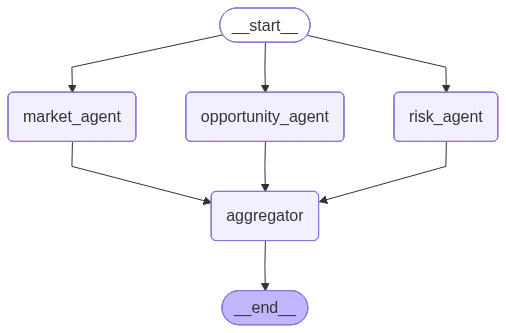

In [18]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(moa_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"시각화 오류: {e}")
    print("\n그래프 구조:")
    print("START -> [market_research / risk_research / opportunity_research] -> aggregator -> END")

# 5. 실행 및 테스트

In [19]:
question = "삼성전자"
print(f"조사 주제: {question}")

print("=" * 70)
result = moa_agent.invoke({"user_input": question})

조사 주제: 삼성전자


In [ ]:
print(result)

{'user_input': '삼성전자', 'market_report': '2026년 6월 4일 기준, 삼성전자에 대한 산업 분석 리포트를 아래와 같이 정리합니다.\n\n1. 현재 시장 규모 및 동향  \n- 2026년 1분기 삼성전자의 연결기준 매출은 약 133.9조원, 영업이익은 57.2조원으로 역대 최대치를 기록했습니다. 매출은 전분기 대비 41.7%, 전년 동기 대비 69% 이상 증가했고, 영업이익은 전분기 대비 185%, 전년 동기 대비 755% 이상 급증하여 대폭 개선된 실적을 보였습니다.  \n- 메모리 반도체 시장은 인공지능(AI) 기술 확산 영향으로 서버용 메모리 수요가 급증하며 전 세계 D램 매출이 1,000억 달러(약 146조원)를 돌파, 전년 동기 대비 80% 이상 급증하는 등 호황을 누리고 있습니다.  \n- D램과 낸드플래시는 가격 상승과 출하량 증가를 동반하며 2026년 1분기 삼성전자는 글로벌 D램 시장 점유율 38.5%, 낸드 시장 점유율 29%로 1위를 공고히 했습니다. SK하이닉스, 마이크론 등 경쟁사와의 격차가 확대되는 추세입니다.  \n- HBM4 및 차세대 저전력 메모리 모듈(SOCAMM2) 양산, PCIe Gen6 SSD 개발 등 첨단 제품을 통한 시장 리더십 강화도 이루어졌습니다.  \n\n2. 주요 플레이어 및 시장 점유율  \n- 삼성전자는 글로벌 반도체 시장 특히 메모리 분야에서 확고한 1위 자리를 유지하고 있습니다.  \n- 1분기 D램 시장 점유율은 38.5%로 SK하이닉스(28.8%), 마이크론(20% 초반대) 등 경쟁사들을 크게 앞서고 있습니다.  \n- 낸드플래시 시장에서도 삼성전자 점유율은 29%로 2위 SK하이닉스(18%) 대비 크게 앞서고 있으며, 일본 키옥시아(14%), 미국 마이크론(13%)이 뒤를 잇고 있습니다.  \n- 중국의 CXMT는 급성장 중이며 점유율이 약 8%로 4위 공급업체로 부상했습니다.  \n\n3. 최근 실적 및 재무 지표  \n- 2026년 1분기 삼성전자(연결기준) 주요 지

In [24]:
print(result.keys())

dict_keys(['user_input', 'market_report', 'risk_report', 'opportunity_report', 'final_answer'])


In [22]:
print(result['user_input'])

삼성전자


In [23]:
print(result['market_report'])

2026년 6월 4일 기준, 삼성전자에 대한 산업 분석 리포트를 아래와 같이 정리합니다.

1. 현재 시장 규모 및 동향  
- 2026년 1분기 삼성전자의 연결기준 매출은 약 133.9조원, 영업이익은 57.2조원으로 역대 최대치를 기록했습니다. 매출은 전분기 대비 41.7%, 전년 동기 대비 69% 이상 증가했고, 영업이익은 전분기 대비 185%, 전년 동기 대비 755% 이상 급증하여 대폭 개선된 실적을 보였습니다.  
- 메모리 반도체 시장은 인공지능(AI) 기술 확산 영향으로 서버용 메모리 수요가 급증하며 전 세계 D램 매출이 1,000억 달러(약 146조원)를 돌파, 전년 동기 대비 80% 이상 급증하는 등 호황을 누리고 있습니다.  
- D램과 낸드플래시는 가격 상승과 출하량 증가를 동반하며 2026년 1분기 삼성전자는 글로벌 D램 시장 점유율 38.5%, 낸드 시장 점유율 29%로 1위를 공고히 했습니다. SK하이닉스, 마이크론 등 경쟁사와의 격차가 확대되는 추세입니다.  
- HBM4 및 차세대 저전력 메모리 모듈(SOCAMM2) 양산, PCIe Gen6 SSD 개발 등 첨단 제품을 통한 시장 리더십 강화도 이루어졌습니다.  

2. 주요 플레이어 및 시장 점유율  
- 삼성전자는 글로벌 반도체 시장 특히 메모리 분야에서 확고한 1위 자리를 유지하고 있습니다.  
- 1분기 D램 시장 점유율은 38.5%로 SK하이닉스(28.8%), 마이크론(20% 초반대) 등 경쟁사들을 크게 앞서고 있습니다.  
- 낸드플래시 시장에서도 삼성전자 점유율은 29%로 2위 SK하이닉스(18%) 대비 크게 앞서고 있으며, 일본 키옥시아(14%), 미국 마이크론(13%)이 뒤를 잇고 있습니다.  
- 중국의 CXMT는 급성장 중이며 점유율이 약 8%로 4위 공급업체로 부상했습니다.  

3. 최근 실적 및 재무 지표  
- 2026년 1분기 삼성전자(연결기준) 주요 지표는 다음과 같습니다.  
  - 매출액: 약 133.9조원 (+43% QoQ, +69% YoY)  

In [25]:
print(result['risk_report'])

[삼성전자 리스크 분석 리포트 - 2026년 6월 4일 기준]

1. 주요 리스크 요인

- 노사관계 및 노동조합 리스크: 삼성전자는 2026년 들어 노동조합이 과반 노조 지위를 공식 취득하며, 성과급 제도화 갈등을 중심으로 노사 대립이 심화되고 있다. 특히 6월 21일부터 18일간의 총파업이 예고되어 있는 상황으로, 파업 시 반도체 생산 라인의 가동 중단으로 인해 최대 30조원에 달하는 막대한 경영상 손실 위험과 더불어 글로벌 고객사와의 공급 신뢰도 저하 우려가 매우 크다.

- 지정학 및 국가경제 영향: 반도체 산업에서 삼성전자가 우리나라 전체 수출의 38%를 차지하는 핵심 역할을 하는 가운데, 생산 차질은 소재·부품·장비(소부장) 협력사 및 국가 경제 전반에 부정적인 파급효과를 미칠 가능성이 높다. 따라서 노조 리스크가 국가 산업 생태계 차원에서도 중대한 리스크로 부상하고 있다.

- 거시경제 및 시장 리스크: 노사 갈등에 따른 대규모 충당금 설정 가능성으로 인해 금융권의 삼성전자 목표주가 조정(예: 씨티그룹 목표가 하향 조정) 및 영업이익 추정치 하향이 이어지고 있다. 이는 단기 실적 부담으로 작용한다.

2. 경쟁 위협 및 시장 포지션 변화 가능성

- 공급망 불안으로 글로벌 AI 및 고성능 반도체(HBM) 시장에서 엔비디아, AMD 등 경쟁사 대비 신뢰도 저하 가능성 대두되며, 삼성전자의 시장 지배력에 부정적 영향을 줄 수 있다.

- 특히 파업 등 생산 차질은 고객사의 물량 확보 불안으로 이어져 브랜드 평판 및 공급망 내 위상이 흔들릴 위험이 커지고 있다.

- 그럼에도 불구하고 삼성전자는 2026년 1분기 133조원 매출, 57조2000억원 영업이익을 기록하며 글로벌 빅테크 최상위권 실적을 유지하고 있어 기본적인 펀더멘털은 견고한 상태임.

3. 기술적 리스크

- 생산시설(반도체 팹)의 특성상 가동 중단 시 복구에 수개월이 소요되며 고가 웨이퍼 폐기 손실 등 직접적 피해 심각.

- 반도체 공급망 신뢰 훼손 가능성으로 인한 AI 반도체 수요 폭

In [26]:
print(result['opportunity_report'])

2026년 6월 4일 기준 삼성전자 기회 분석 리포트

1. 핵심 성장 동력 및 촉매 요인
- AI 중심 사업 역량 집중: 삼성전자는 2026년 경영전략에서 ‘AI’를 핵심 성장 엔진으로 삼아 전사적 역량을 집중하고 있다. AI 수요 폭증에 대응하기 위해 AI 반도체, AI 탑재 디바이스 등 전 제품과 서비스에 AI를 내재화하는 ‘AI 전환기 선도’ 전략을 내세웠다.
- 종합 AI 반도체 솔루션 기업 경쟁력 강화: 메모리, 로직, 파운드리, 패키징까지 아우르는 원스톱 AI 반도체 생태계를 구축해 AI용 고부가가치 제품 판매를 확대하며 시장 지배력을 강화하고 있다. 특히 4세대 고대역폭 메모리(HBM4), 차세대 모바일 AP 엑시노스 2600 등의 초격차 기술이 촉매 역할을 한다.
- DX 부문의 AI 내재화 및 혁신: 갤럭시 S26, Z 트라이폴드 등 플래그십 스마트폰으로 프리미엄 제품 판매를 확대하고, AI 연계 스마트 기기·서비스 혁신으로 소비자 경험을 차별화하고 있다.
- 연구개발과 시설투자 지속 확대: 1분기에만 연구개발비 11.3조원을 집행, AI·6G·로보틱스 등 신기술 분야에 선제적 투자로 미래 성장 동력을 확보 중이다.
- 글로벌 시장 및 환율 변수 활용: 주요 통화 대비 원화 환율 상승이 수출 중심 수익구조에 약 1.8조원의 긍정적 환영향을 제공 중이다.

2. 신기술/신사업 기회
- AI 반도체 시장 주도권 확보: 글로벌 AI 반도체 수요 확대 속에서 상호 통합된 설계·공정·패키징 역량을 통해 종합 AI 솔루션 제공자로서 경쟁 우위 확보 가능.
- 6G 및 차세대 통신 기술: 삼성전자는 6G 연구개발에도 집중하여 통신 네트워크 혁신과 연동된 제품·서비스 혁신이 기대된다.
- 로보틱스 및 메드테크 산업 진출: AI 및 하드웨어 기술을 접목한 로보틱스, 의료기술 영역에서 신성장 동력 창출 가능.
- 폴더블·확장형 스마트 기기: 갤럭시 Z 트라이폴드 등 혁신적 모바일 폼팩터를 통한 새로운 사용자 경험 제공으로 시장 차별화.

3. 투자 관점에서의 

In [27]:
print(result['final_answer'])

# [삼성전자] 통합 조사 보고서 (2026년 6월 기준)

---

## 머리말

본 보고서는 2026년 6월 4일 기준, 삼성전자의 시장 현황, 주요 리스크, 투자 기회 및 성장 동력을 종합적으로 분석한 결과를 담고 있습니다. AI 및 고성능 반도체 시장의 구조적 변화, 노사 리스크 등 복합적 환경 속에서 삼성전자의 경쟁력과 미래 전략을 다각도로 평가하였습니다.

---

## Executive Summary

삼성전자는 2026년 1분기 사상 최대 실적을 기록하며 글로벌 반도체 시장, 특히 AI 및 서버용 메모리 분야에서 확고한 리더십을 입증했습니다. AI 중심의 사업 전략, 첨단 반도체 기술, 공격적 R&D 투자 등으로 중장기 성장 모멘텀을 확보하고 있습니다. 다만, 노사관계 악화에 따른 생산 차질 리스크가 단기적으로 실적과 글로벌 공급망 신뢰에 중대한 위협으로 부상하고 있어, 이에 대한 대응이 핵심 과제로 부각됩니다.

---

## 시장 현황 및 동향

### 1. 시장 규모 및 동향

- 2026년 1분기 삼성전자 매출 133.9조원(+43% QoQ, +69% YoY), 영업이익 57.2조원(+185% QoQ, +756% YoY)로 역대 최대 실적 달성.
- AI 확산에 힘입어 서버용 메모리 수요가 폭증, 글로벌 D램 매출 1,000억 달러 돌파(전년 동기 대비 +80% 이상).
- 삼성전자는 D램(38.5%), 낸드(29%) 시장 점유율 1위, 경쟁사와의 격차 확대.
- HBM4, SOCAMM2, PCIe Gen6 SSD 등 첨단 제품 양산 및 개발로 시장 리더십 강화.
- DS(반도체) 부문이 전체 영업이익의 94% 차지, DX(스마트폰 등) 부문은 신제품 효과로 매출 증가.

### 2. 시장 전망

- 2026년 2분기 DRAM/NAND 가격 추가 상승 전망, AI·LLM 기반 B2B 솔루션 도입 가속화로 서버용 메모리 수요 지속 증가 예상.
- 파운드리 선단공정 가동률 최고치, 고성능 컴퓨팅 시장 중심 성장.
- 2027년 HBM 가격 5